In [1]:
import pandas as pd
import re

In [2]:
# Book dataset information

book_names_df = pd.read_csv('book_titles.csv')
book_names_df.describe()

,Unnamed: 0,text_reviews_count,average_rating,num_pages,publication_day,publication_month,publication_year,book_id,ratings_count,work_id
count,6301.000000,6301.000000,6301.000000,5968.000000,5362.000000,5505.000000,5622.000000,6.301000e+03,6.301000e+03,6.301000e+03
mean,3150.000000,2652.332804,3.972349,346.728887,14.029280,6.303724,2011.162220,1.393600e+07,5.144573e+04,2.112064e+07
std,1819.086355,6319.195025,0.274742,144.932054,9.772724,3.274454,5.550981,9.537153e+06,1.955803e+05,1.618190e+07
min,0.000000,20.000000,2.460000,1.000000,1.000000,1.000000,1950.000000,1.000000e+00,4.200000e+01,1.140000e+02
25%,1575.000000,332.000000,3.810000,274.000000,5.000000,4.000000,2010.000000,6.492981e+06,2.561000e+03,6.405906e+06
50%,3150.000000,825.000000,3.990000,336.000000,13.000000,6.000000,2013.000000,1.361296e+07,8.227000e+03,1.884156e+07
75%,4725.000000,2268.000000,4.160000,401.000000,23.000000,9.000000,2014.000000,2.141385e+07,2.861300e+04,3.117587e+07
max,6300.000000,142645.000000,4.770000,1859.000000,31.000000,12.000000,2018.000000,3.625277e+07,4.899965e+06,5.799794e+07


In [3]:
book_names_df.columns

Index(['Unnamed: 0', 'isbn', 'text_reviews_count', 'series', 'country_code',
       'language_code', 'popular_shelves', 'asin', 'is_ebook',
       'average_rating', 'kindle_asin', 'similar_books', 'description',
       'format', 'link', 'authors', 'publisher', 'num_pages',
       'publication_day', 'isbn13', 'publication_month', 'edition_information',
       'publication_year', 'url', 'image_url', 'book_id', 'ratings_count',
       'work_id', 'title', 'title_without_series'],
      dtype='object')

In [4]:
book_descriptions_df = book_names_df[[
    'book_id','title','description','average_rating','similar_books','image_url','ratings_count','publication_year',
    'authors','num_pages'
]]

# Because there are many missing value in the 'isbn' column, we're keeping the 'book_id' instead of 'isbn'

In [5]:
book_descriptions_df.isnull().sum()

book_id               0
title                 0
description          49
average_rating        0
similar_books         0
image_url             0
ratings_count         0
publication_year    679
authors               0
num_pages           333
dtype: int64

In [6]:
book_descriptions_df.loc[:,'publication_year'] = book_descriptions_df['publication_year'].fillna('unknown')
book_descriptions_df.loc[:,'num_pages'] = book_descriptions_df['num_pages'].fillna('unknown')
book_descriptions_df.dropna()

/var/folders/sd/89k8f2590j3gdmx801d3dzhh0000gn/T/ipykernel_89584/1370129349.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2005.0 2013.0 'unknown' ... 2015.0 2010.0 2007.0]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  book_descriptions_df.loc[:,'publication_year'] = book_descriptions_df['publication_year'].fillna('unknown')
/var/folders/sd/89k8f2590j3gdmx801d3dzhh0000gn/T/ipykernel_89584/1370129349.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[360.0 277.0 360.0 ... 400.0 400.0 240.0]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  book_descriptions_df.loc[:,'num_pages'] = book_descriptions_df['num_pages'].fillna('unknown')


,book_id,title,description,average_rating,similar_books,image_url,ratings_count,publication_year,authors,num_pages
0,38568,A Quick Bite (Argeneau #1),That hot guy tied to Lissianna Argeneau's bed?...,3.91,"['225669', '50789', '383143', '293616', '75960...",https://images.gr-assets.com/books/1410129015m...,32140,2005.0,"[{'author_id': '17059', 'role': ''}]",360.0
1,16107050,Tied (Fire Born #1),Normal people don't believe their nightmares s...,3.45,"['18074687', '18692520', '25679123', '25744874...",https://images.gr-assets.com/books/1361793669m...,79,2013.0,"[{'author_id': '6563682', 'role': ''}]",277.0
2,19057,I Am the Messenger,protect the diamonds\nsurvive the clubs\ndig d...,4.09,"['1121894', '99375', '233906', '824499', '1006...",https://images.gr-assets.com/books/1398483261m...,94968,unknown,"[{'author_id': '11466', 'role': ''}]",360.0
3,17333426,"Egghead: Or, You Can't Survive on Ideas Alone",A strange and charming collection of hilarious...,4.12,"['15824233', '13152144', '13529076', '18369456...",https://images.gr-assets.com/books/1400879372m...,6461,2013.0,"[{'author_id': '5370407', 'role': ''}, {'autho...",240.0
4,19398490,All the Light We Cannot See,Winner of the Pulitzer Prize\nFrom the highly ...,4.31,"['11807189', '11529868', '17332207', '13593526...",https://images.gr-assets.com/books/1440903901m...,53342,2014.0,"[{'author_id': '28186', 'role': ''}]",531.0
...,...,...,...,...,...,...,...,...,...,...
6295,16097364,"Severed Heads, Broken Hearts","Robyn Schneider's book, originally titled Seve...",3.77,"['16065521', '14290962', '12157780', '15721669...",https://images.gr-assets.com/books/1374501795m...,1119,2013.0,"[{'author_id': '50568', 'role': ''}]",288.0
6296,32766757,No Good Deed,Ellie Hudson is the front-runner on the road t...,3.85,[],https://images.gr-assets.com/books/1481308695m...,295,2017.0,"[{'author_id': '16014964', 'role': ''}]",352.0
6297,17061,Coraline,'An electrifyingly creepy tale likely to haunt...,4.03,"['2934112', '24774', '13538708', '34501', '371...",https://images.gr-assets.com/books/1493497435m...,325562,2006.0,"[{'author_id': '1221698', 'role': ''}]",162.0
6298,24397043,The Hollow Boy (Lockwood & Co. #3),As a massive outbreak of supernatural Visitors...,4.36,"['24611884', '17464884', '20706799', '18405537...",https://images.gr-assets.com/books/1429031246m...,6088,2015.0,"[{'author_id': '33467', 'role': ''}]",400.0


In [7]:
authors_df = pd.read_csv('authors.csv')
authors_df.head()

,Unnamed: 0,average_rating,author_id,text_reviews_count,name,ratings_count
0,0,3.98,604031,7,Ronald J. Fields,49
1,1,4.08,626222,28716,Anita Diamant,546796
2,2,3.92,10333,5075,Barbara Hambly,122118
3,3,3.68,9212,36262,Jennifer Weiner,888522
4,4,3.82,149918,96,Nigel Pennick,1740


In [8]:
# Functions copied from Gemini
import ast
# Convert string to list for each row in 'authors'
book_descriptions_df.loc[:,'authors'] = book_descriptions_df['authors'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
)
def extract_first_author_id(author_list):
    if isinstance(author_list, list) and len(author_list) > 0:
        return str(author_list[0].get('author_id'))
    return None

book_descriptions_df.loc[:,'author_id'] = book_descriptions_df['authors'].apply(extract_first_author_id)


/var/folders/sd/89k8f2590j3gdmx801d3dzhh0000gn/T/ipykernel_89584/3634081987.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  book_descriptions_df.loc[:,'author_id'] = book_descriptions_df['authors'].apply(extract_first_author_id)


In [9]:
book_descriptions_df.head()

,book_id,title,description,average_rating,similar_books,image_url,ratings_count,publication_year,authors,num_pages,author_id
0,38568,A Quick Bite (Argeneau #1),That hot guy tied to Lissianna Argeneau's bed?...,3.91,"['225669', '50789', '383143', '293616', '75960...",https://images.gr-assets.com/books/1410129015m...,32140,2005.0,"[{'author_id': '17059', 'role': ''}]",360.0,17059
1,16107050,Tied (Fire Born #1),Normal people don't believe their nightmares s...,3.45,"['18074687', '18692520', '25679123', '25744874...",https://images.gr-assets.com/books/1361793669m...,79,2013.0,"[{'author_id': '6563682', 'role': ''}]",277.0,6563682
2,19057,I Am the Messenger,protect the diamonds\nsurvive the clubs\ndig d...,4.09,"['1121894', '99375', '233906', '824499', '1006...",https://images.gr-assets.com/books/1398483261m...,94968,unknown,"[{'author_id': '11466', 'role': ''}]",360.0,11466
3,17333426,"Egghead: Or, You Can't Survive on Ideas Alone",A strange and charming collection of hilarious...,4.12,"['15824233', '13152144', '13529076', '18369456...",https://images.gr-assets.com/books/1400879372m...,6461,2013.0,"[{'author_id': '5370407', 'role': ''}, {'autho...",240.0,5370407
4,19398490,All the Light We Cannot See,Winner of the Pulitzer Prize\nFrom the highly ...,4.31,"['11807189', '11529868', '17332207', '13593526...",https://images.gr-assets.com/books/1440903901m...,53342,2014.0,"[{'author_id': '28186', 'role': ''}]",531.0,28186


In [10]:
# Add authors' names to the dataset 

author_id_to_name = dict(zip(authors_df['author_id'].astype(str), authors_df['name']))
book_descriptions_df.loc[:,'author_name'] = book_descriptions_df['author_id'].map(author_id_to_name)
book_descriptions_df.head()

/var/folders/sd/89k8f2590j3gdmx801d3dzhh0000gn/T/ipykernel_89584/241420533.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  book_descriptions_df.loc[:,'author_name'] = book_descriptions_df['author_id'].map(author_id_to_name)


,book_id,title,description,average_rating,similar_books,image_url,ratings_count,publication_year,authors,num_pages,author_id,author_name
0,38568,A Quick Bite (Argeneau #1),That hot guy tied to Lissianna Argeneau's bed?...,3.91,"['225669', '50789', '383143', '293616', '75960...",https://images.gr-assets.com/books/1410129015m...,32140,2005.0,"[{'author_id': '17059', 'role': ''}]",360.0,17059,Lynsay Sands
1,16107050,Tied (Fire Born #1),Normal people don't believe their nightmares s...,3.45,"['18074687', '18692520', '25679123', '25744874...",https://images.gr-assets.com/books/1361793669m...,79,2013.0,"[{'author_id': '6563682', 'role': ''}]",277.0,6563682,Laney McMann
2,19057,I Am the Messenger,protect the diamonds\nsurvive the clubs\ndig d...,4.09,"['1121894', '99375', '233906', '824499', '1006...",https://images.gr-assets.com/books/1398483261m...,94968,unknown,"[{'author_id': '11466', 'role': ''}]",360.0,11466,Markus Zusak
3,17333426,"Egghead: Or, You Can't Survive on Ideas Alone",A strange and charming collection of hilarious...,4.12,"['15824233', '13152144', '13529076', '18369456...",https://images.gr-assets.com/books/1400879372m...,6461,2013.0,"[{'author_id': '5370407', 'role': ''}, {'autho...",240.0,5370407,Bo Burnham
4,19398490,All the Light We Cannot See,Winner of the Pulitzer Prize\nFrom the highly ...,4.31,"['11807189', '11529868', '17332207', '13593526...",https://images.gr-assets.com/books/1440903901m...,53342,2014.0,"[{'author_id': '28186', 'role': ''}]",531.0,28186,Anthony Doerr


In [11]:
book_df = book_descriptions_df[[
    'book_id','title','description','average_rating','similar_books','image_url','ratings_count','publication_year',
    'author_name','num_pages'
]]

In [12]:
book_df.head()

,book_id,title,description,average_rating,similar_books,image_url,ratings_count,publication_year,author_name,num_pages
0,38568,A Quick Bite (Argeneau #1),That hot guy tied to Lissianna Argeneau's bed?...,3.91,"['225669', '50789', '383143', '293616', '75960...",https://images.gr-assets.com/books/1410129015m...,32140,2005.0,Lynsay Sands,360.0
1,16107050,Tied (Fire Born #1),Normal people don't believe their nightmares s...,3.45,"['18074687', '18692520', '25679123', '25744874...",https://images.gr-assets.com/books/1361793669m...,79,2013.0,Laney McMann,277.0
2,19057,I Am the Messenger,protect the diamonds\nsurvive the clubs\ndig d...,4.09,"['1121894', '99375', '233906', '824499', '1006...",https://images.gr-assets.com/books/1398483261m...,94968,unknown,Markus Zusak,360.0
3,17333426,"Egghead: Or, You Can't Survive on Ideas Alone",A strange and charming collection of hilarious...,4.12,"['15824233', '13152144', '13529076', '18369456...",https://images.gr-assets.com/books/1400879372m...,6461,2013.0,Bo Burnham,240.0
4,19398490,All the Light We Cannot See,Winner of the Pulitzer Prize\nFrom the highly ...,4.31,"['11807189', '11529868', '17332207', '13593526...",https://images.gr-assets.com/books/1440903901m...,53342,2014.0,Anthony Doerr,531.0


In [13]:
book_df.isnull().sum()

book_id              0
title                0
description         49
average_rating       0
similar_books        0
image_url            0
ratings_count        0
publication_year     0
author_name          0
num_pages            0
dtype: int64

In [14]:
book_df = book_df.dropna()

In [15]:
# Function to clean up the descriptions

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<.*?>", "", text)       # Remove HTML tags
    text = re.sub(r"[\r\n]+", " ", text)    # Remove line breaks
    text = re.sub(r"\s+", " ", text)        # Remove space
    text = text.replace(r"\'", "'")         # Replace escaped apostrophes
    return text.strip().lower()

In [16]:
# Clean up description

book_df['cleaned_description'] = book_descriptions_df['description'].apply(clean_text)
book_df

,book_id,title,description,average_rating,similar_books,image_url,ratings_count,publication_year,author_name,num_pages,cleaned_description
0,38568,A Quick Bite (Argeneau #1),That hot guy tied to Lissianna Argeneau's bed?...,3.91,"['225669', '50789', '383143', '293616', '75960...",https://images.gr-assets.com/books/1410129015m...,32140,2005.0,Lynsay Sands,360.0,that hot guy tied to lissianna argeneau's bed?...
1,16107050,Tied (Fire Born #1),Normal people don't believe their nightmares s...,3.45,"['18074687', '18692520', '25679123', '25744874...",https://images.gr-assets.com/books/1361793669m...,79,2013.0,Laney McMann,277.0,normal people don't believe their nightmares s...
2,19057,I Am the Messenger,protect the diamonds\nsurvive the clubs\ndig d...,4.09,"['1121894', '99375', '233906', '824499', '1006...",https://images.gr-assets.com/books/1398483261m...,94968,unknown,Markus Zusak,360.0,protect the diamonds survive the clubs dig dee...
3,17333426,"Egghead: Or, You Can't Survive on Ideas Alone",A strange and charming collection of hilarious...,4.12,"['15824233', '13152144', '13529076', '18369456...",https://images.gr-assets.com/books/1400879372m...,6461,2013.0,Bo Burnham,240.0,a strange and charming collection of hilarious...
4,19398490,All the Light We Cannot See,Winner of the Pulitzer Prize\nFrom the highly ...,4.31,"['11807189', '11529868', '17332207', '13593526...",https://images.gr-assets.com/books/1440903901m...,53342,2014.0,Anthony Doerr,531.0,winner of the pulitzer prize from the highly a...
...,...,...,...,...,...,...,...,...,...,...,...
6295,16097364,"Severed Heads, Broken Hearts","Robyn Schneider's book, originally titled Seve...",3.77,"['16065521', '14290962', '12157780', '15721669...",https://images.gr-assets.com/books/1374501795m...,1119,2013.0,Robyn Schneider,288.0,"robyn schneider's book, originally titled seve..."
6296,32766757,No Good Deed,Ellie Hudson is the front-runner on the road t...,3.85,[],https://images.gr-assets.com/books/1481308695m...,295,2017.0,Kara Connolly,352.0,ellie hudson is the front-runner on the road t...
6297,17061,Coraline,'An electrifyingly creepy tale likely to haunt...,4.03,"['2934112', '24774', '13538708', '34501', '371...",https://images.gr-assets.com/books/1493497435m...,325562,2006.0,Neil Gaiman,162.0,'an electrifyingly creepy tale likely to haunt...
6298,24397043,The Hollow Boy (Lockwood & Co. #3),As a massive outbreak of supernatural Visitors...,4.36,"['24611884', '17464884', '20706799', '18405537...",https://images.gr-assets.com/books/1429031246m...,6088,2015.0,Jonathan Stroud,400.0,as a massive outbreak of supernatural visitors...


In [17]:
# Add a description word count column, then use this to visualize the distribution of the word counts

book_df['words_in_description'] = book_df['cleaned_description'].str.split().str.len()

In [18]:
import matplotlib.pyplot as plt

In [19]:
# Define bin edges and labels
bins = [0, 9, 25, 500, float('inf')]
labels = ['<10', '10-25', '26-500', '>500']

# Create a new column for binned categories
book_df['description_length_bin'] = pd.cut(
    book_df['words_in_description'], bins=bins, labels=labels, right=True
)

In [20]:
length_counts = book_df['description_length_bin'].value_counts().sort_index()

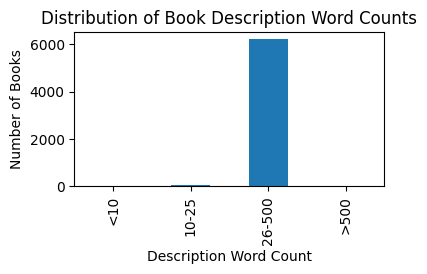

In [21]:
plt.figure(figsize=(4,2))
length_counts.plot(kind='bar')
plt.xlabel('Description Word Count')
plt.ylabel('Number of Books')
plt.title('Distribution of Book Description Word Counts')
plt.show()

In [22]:
# We will keep books with description word counts between 26-500

book_df = book_df[(book_df['words_in_description'] >= 26) & (book_df['words_in_description'] <= 500)]

In [24]:
#book_df.to_csv('book_descriptions.csv', index=False)

In [25]:
len(book_df)

6219

Embedding

In [26]:
from sentence_transformers import SentenceTransformer
import joblib

In [27]:
descriptions = book_df['cleaned_description']

In [28]:
model = SentenceTransformer('all-MiniLM-L6-v2')
descriptions = descriptions.reset_index(drop=True)
description_embedding = model.encode(descriptions.tolist())

Vector Search

In [29]:
import torch
import torch.nn.functional as f

In [30]:
# Convert numpy to torch

description_embedding = torch.tensor(description_embedding)



In [51]:
# An example input
query = "A novel that is about love but scary at the same time."

In [52]:
query_embedding = model.encode([query], convert_to_tensor=True)

In [53]:
# Compute cosine similarity between each description and the query
cos_sim = torch.nn.functional.cosine_similarity(description_embedding, query_embedding, dim=1)

In [54]:


# Get top-k similar descriptions
k = 10
top_k = torch.topk(cos_sim, k=k)

# Results
for i, (score, idx) in enumerate(zip(top_k.values, top_k.indices)):
    idx = idx.item()
    book_title = book_df.iloc[idx]['title']
    book_description = book_df.iloc[idx]['description']
    author = book_df.iloc[idx]['author_name']  # or ['authors'] if that's your column
    publish_year = book_df.iloc[idx]['publication_year']

    print(f"Rank {i+1} | Cos_Sim Score: {score:.4f}")
    print(f"Book Title: {book_title}")
    print(f"Author: {author}")
    print(f"Published in: {publish_year}")
    print(f"Book description: {book_description}")
    print("-------------------------------")

Rank 1 | Cos_Sim Score: 0.5932
Book Title: Giovanni's Room
Author: James     Baldwin
Published in: 2000.0
Book description: An alternate cover for this ISBN can be found .
Baldwin's haunting and controversial second novel is his most sustained treatment of sexuality, and a classic of gay literature. In a 1950s Paris swarming with expatriates and characterized by dangerous liaisons and hidden violence, an American finds himself unable to repress his impulses, despite his determination to live the conventional life he envisions for himself. After meeting and proposing to a young woman, he falls into a lengthy affair with an Italian bartender and is confounded and tortured by his sexual identity as he oscillates between the two.
Examining the mystery of love and passion in an intensely imagined narrative, Baldwin creates a moving and complex story of death and desire that is revelatory in its insight.
-------------------------------
Rank 2 | Cos_Sim Score: 0.5922
Book Title: Slasher Girl